<div id="sec1" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">1.&nbsp;&nbsp;Loading Data &amp; Libraries</h1>
</div>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


<div id="sec2" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">2.&nbsp;&nbsp;EDA (Exploratory Data Analysis)</h1>
</div>

<div id="sec2-1" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.1&nbsp;&nbsp;Understanding the Data</h2>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [4]:
df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [5]:
df.sample()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
321788,321788,42,102679.0,5.0,1,0,8,1.0,Male,Suburban,Sedan,Yes,No,Low,No


In [6]:
df.groupby('Current_Car_Type')['Will_Buy_EV'].value_counts(normalize=True)

Current_Car_Type  Will_Buy_EV
Hatchback         No             0.825701
                  Yes            0.174299
SUV               No             0.819047
                  Yes            0.180953
Sedan             No             0.828033
                  Yes            0.171967
Truck             No             0.843587
                  Yes            0.156413
Name: proportion, dtype: float64

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">EV purchase rate barely varies across <code>Current_Car_Type</code> (17.1%–18.1% across Hatchback/SUV/Sedan/Truck) &mdash; a weak signal on its own, confirmed later when this feature's model importance turns out to be minimal.</li>
</ul>
</div>

<div id="sec2-2" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.2&nbsp;&nbsp;Data Cleaning</h2>
</div>

In [7]:
df.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

`Dataset has No Null & No Duplicates values`

<div id="sec2-3" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.3&nbsp;&nbsp;Data Visualization</h2>
</div>

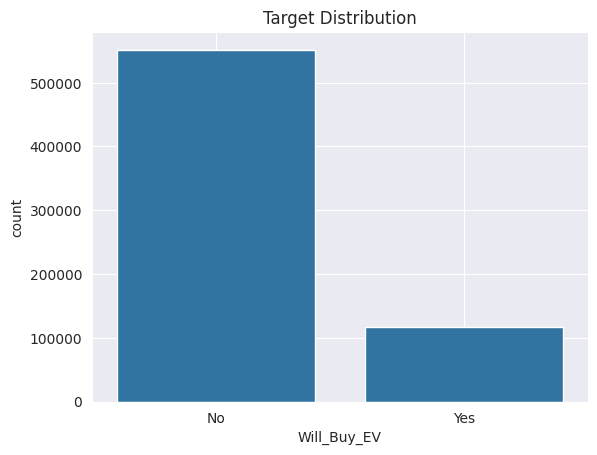

In [9]:
sns.set_style("dark")

sns.countplot(data=df, x="Will_Buy_EV")
plt.title("Target Distribution")
plt.grid(True)
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">The target is imbalanced at roughly 82.5% No / 17.5% Yes (~4.7:1) &mdash; moderate, not extreme, but enough to distort accuracy/F1 at a default 0.5 threshold if not handled carefully.</li>
</ul>
</div>

In [10]:
df.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

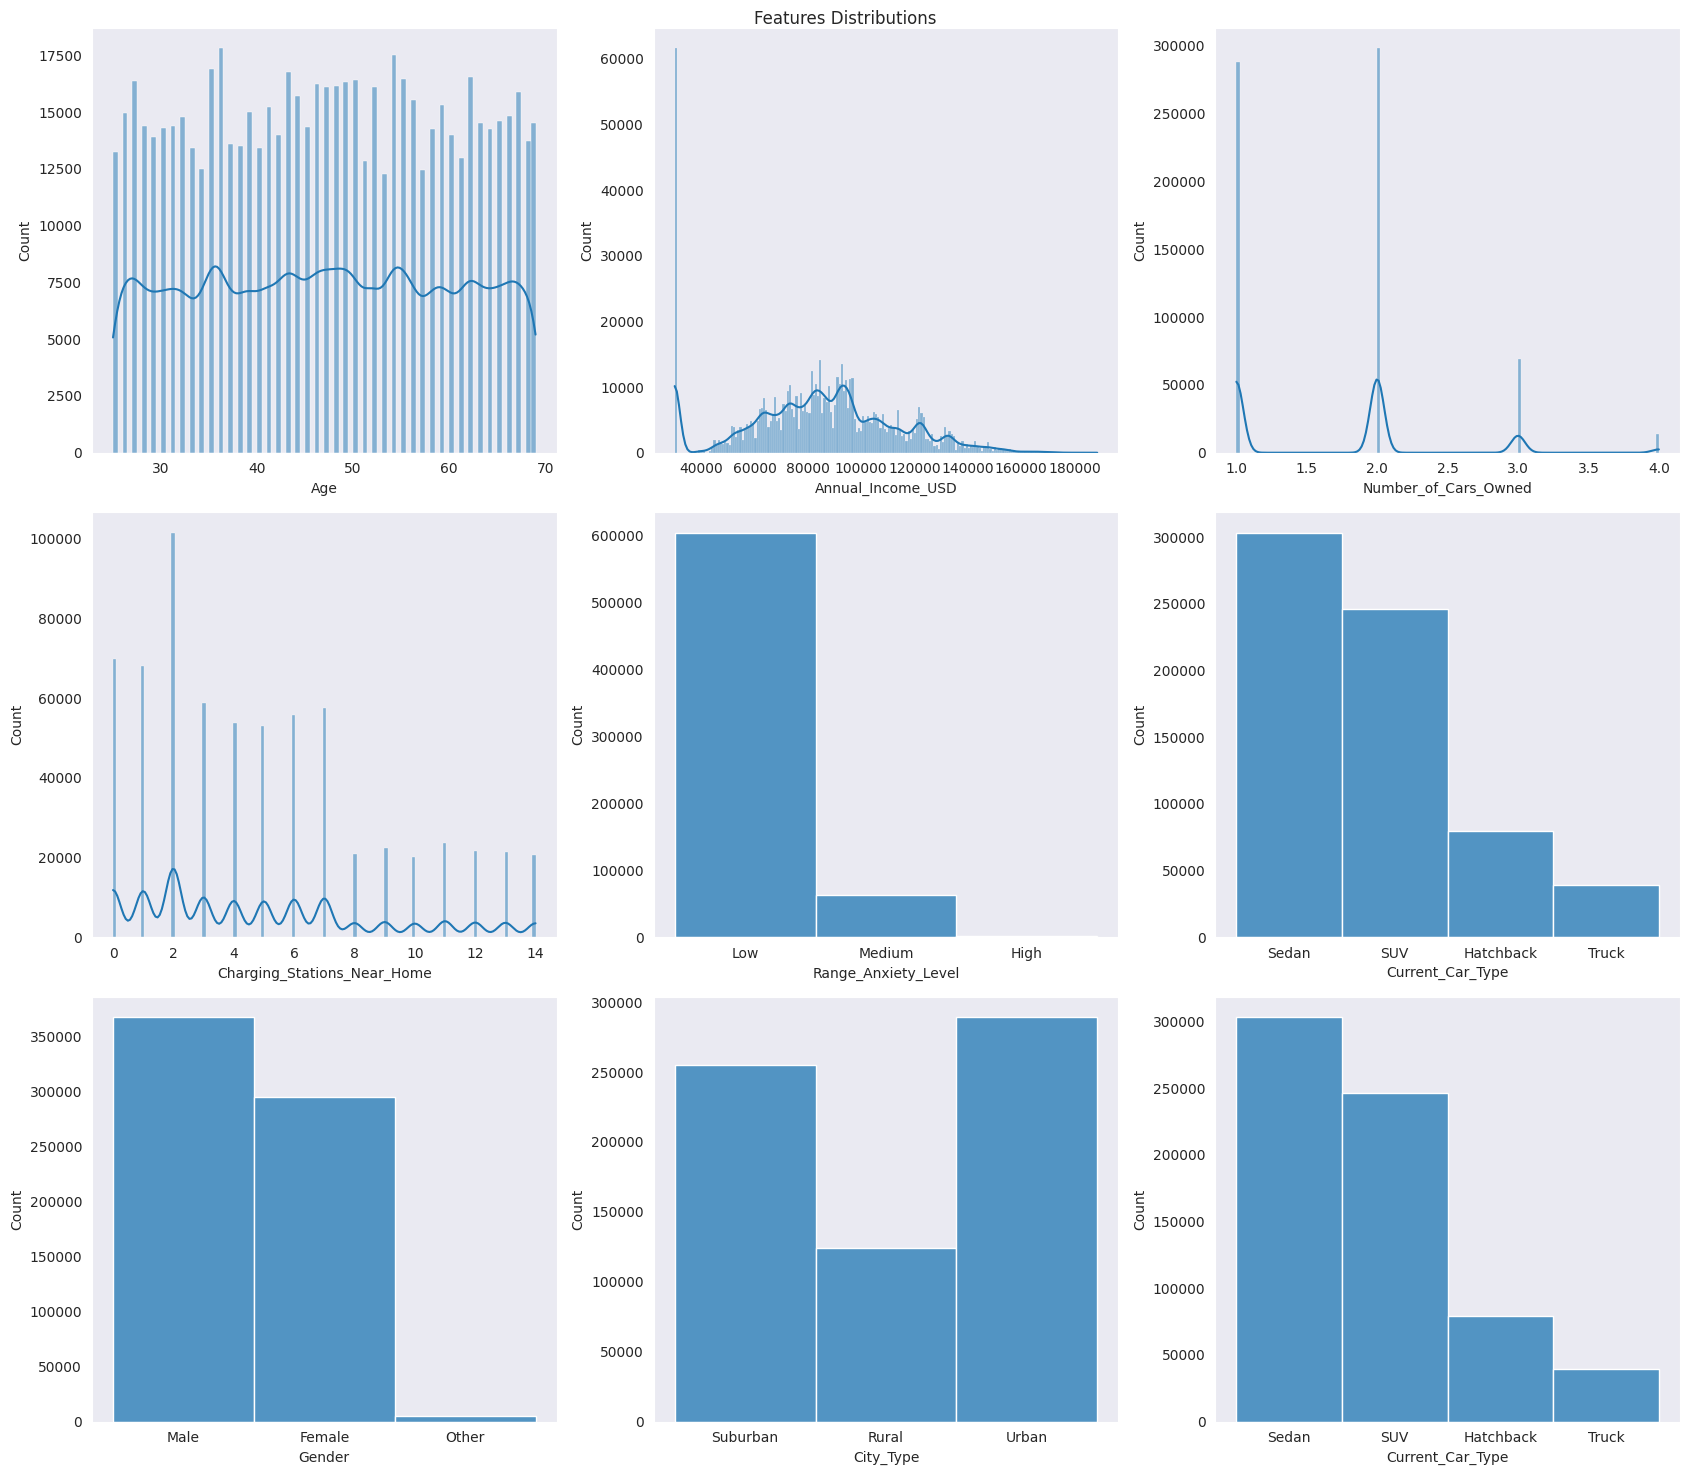

In [11]:
fig, axes = plt.subplots(3,3, figsize=(17,15))

sns.histplot(ax=axes[0,0], data=df, x="Age", kde=True)
sns.histplot(ax=axes[0,1], data=df, x="Annual_Income_USD", kde=True)
sns.histplot(ax=axes[0,2], data=df, x="Number_of_Cars_Owned", kde=True)
sns.histplot(ax=axes[1,0], data=df, x="Charging_Stations_Near_Home", kde=True)
sns.histplot(ax=axes[1,1], data=df, x="Range_Anxiety_Level")
sns.histplot(ax=axes[1,2], data=df, x="Current_Car_Type")
sns.histplot(ax=axes[2,0], data=df, x="Gender")
sns.histplot(ax=axes[2,1], data=df, x="City_Type")
sns.histplot(ax=axes[2,2], data=df, x="Current_Car_Type")

plt.suptitle("Features Distributions")
plt.tight_layout()
plt.show()

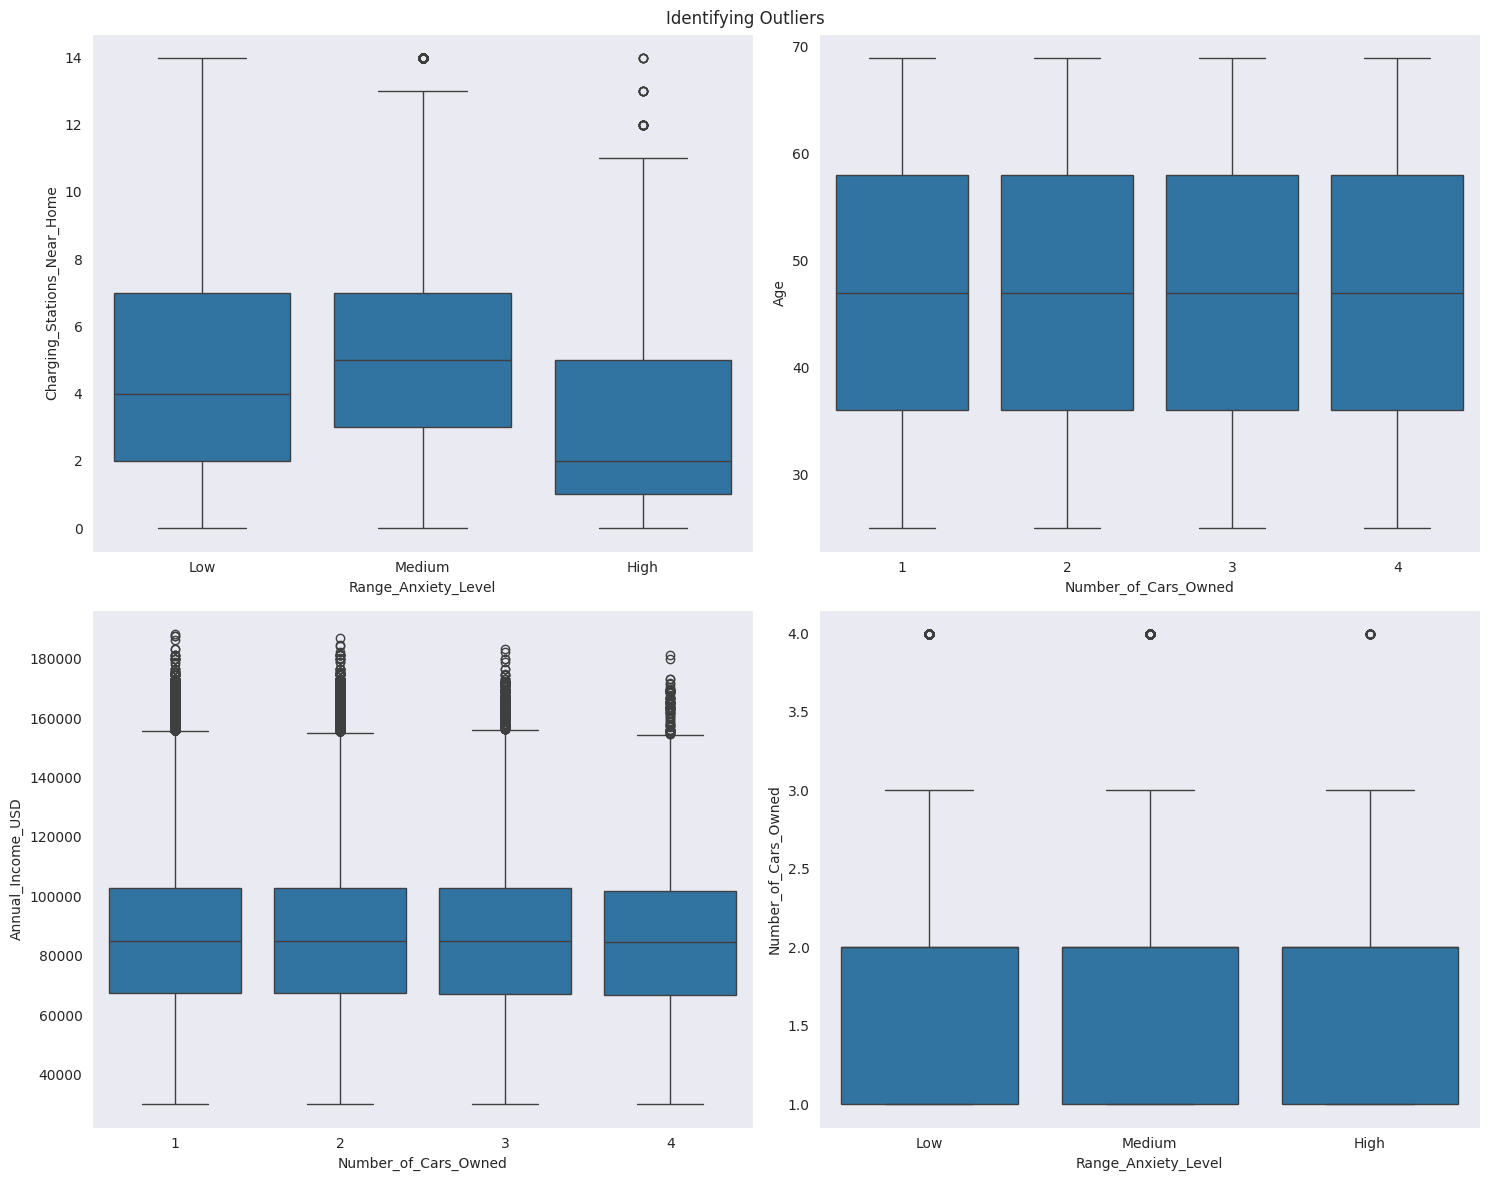

In [12]:
fig, axes = plt.subplots(2,2, figsize=(15,12))

sns.boxplot(ax=axes[0,0], data=df, x="Range_Anxiety_Level", y="Charging_Stations_Near_Home")
sns.boxplot(ax=axes[0,1], data=df, x="Number_of_Cars_Owned", y="Age")
sns.boxplot(ax=axes[1,0], data=df, x="Number_of_Cars_Owned", y="Annual_Income_USD")
sns.boxplot(ax=axes[1,1], data=df, x="Range_Anxiety_Level", y="Number_of_Cars_Owned")

plt.suptitle("Identifying Outliers")
plt.tight_layout()
plt.show()

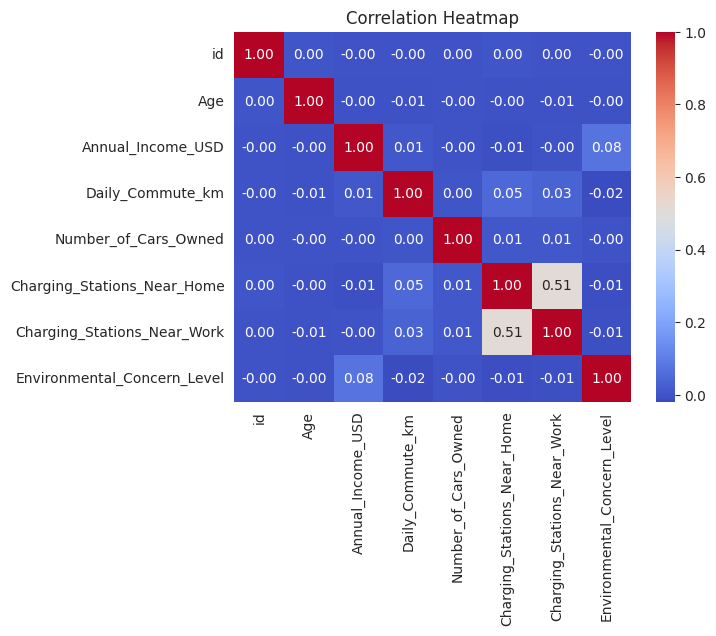

In [13]:
numerical_cols = df.select_dtypes(include="number")
corr_matrix = numerical_cols.corr()

sns.heatmap(
    corr_matrix,
    fmt=".2f",
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

<div id="sec3" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">3.&nbsp;&nbsp;Feature Engineering</h1>
</div>

<div id="sec3-1" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.1&nbsp;&nbsp;Feature Encoding</h2>
</div>

In [14]:
# Feature Encoding
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("Feature (",col, ") Value Counts")
    print(df[col].value_counts())

Feature ( Gender ) Value Counts
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64
Feature ( City_Type ) Value Counts
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64
Feature ( Current_Car_Type ) Value Counts
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64
Feature ( Home_Charging_Possible ) Value Counts
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64
Feature ( Subsidy_Available ) Value Counts
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64
Feature ( Range_Anxiety_Level ) Value Counts
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64
Feature ( Will_Buy_EV ) Value Counts
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


In [15]:
# Using Label Encoding

from sklearn.preprocessing import LabelEncoder

charging_le = LabelEncoder()
df["Home_Charging_Possible"] = charging_le.fit_transform(df["Home_Charging_Possible"])

subsidy_le = LabelEncoder()
df["Subsidy_Available"] = subsidy_le.fit_transform(df["Subsidy_Available"])

target_le = LabelEncoder()
df["Will_Buy_EV"] = target_le.fit_transform(df["Will_Buy_EV"])

# Using Map

df["Range_Anxiety_Level"] = df["Range_Anxiety_Level"].map({"Low":0, "Medium":1, "High":2}) 
df["Gender"] = df["Gender"].map({"Male":0, "Female":1, "Other":2}) 

In [16]:
# Using OneHot Encoding
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_col = ohe.fit_transform(df[["City_Type"]])
encoded_df = pd.DataFrame(encoded_col, columns=ohe.get_feature_names_out(["City_Type"]), index=df.index)
df = pd.concat([df.drop(columns="City_Type"), encoded_df], axis=1)

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_col = ohe.fit_transform(df[["Current_Car_Type"]])
encoded_df = pd.DataFrame(encoded_col, columns=ohe.get_feature_names_out(["Current_Car_Type"]), index=df.index)
df = pd.concat([df.drop(columns="Current_Car_Type"), encoded_df], axis=1)

cols = [c for c in df.columns if c != "Will_Buy_EV"] + ["Will_Buy_EV"]
df = df[cols]

df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,0,1,0,0,1.0,0.0,0.0,1.0,0.0,0
1,1,38,30000.0,5.0,1,2,2,4.0,0,1,0,0,0.0,0.0,1.0,0.0,0.0,0
2,2,26,94389.0,36.8,1,8,15,5.0,1,0,1,0,0.0,1.0,0.0,1.0,0.0,1
3,3,66,73580.0,23.7,2,6,9,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0
4,4,54,57898.0,50.8,1,2,3,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0


In [17]:
print(df.loc[0, ['City_Type_Suburban','City_Type_Urban','Current_Car_Type_SUV','Current_Car_Type_Sedan','Current_Car_Type_Truck','Will_Buy_EV']])

City_Type_Suburban        1.0
City_Type_Urban           0.0
Current_Car_Type_SUV      0.0
Current_Car_Type_Sedan    1.0
Current_Car_Type_Truck    0.0
Will_Buy_EV               0.0
Name: 0, dtype: float64


<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;"><b>Bug found &amp; fixed:</b> the original reordering line <code>df.columns = [c for c in df.columns if c != "Will_Buy_EV"] + ["Will_Buy_EV"]</code> only relabeled columns &mdash; it never moved the underlying data &mdash; which silently shifted every column from <code>Will_Buy_EV</code> onward by one position and corrupted the target used for training.</li><li style="margin-bottom:4px;">Fixed with <code>df = df[cols]</code>, which actually reorders the data by column name. Verified by checking row 0's values against the raw CSV after the fix.</li><li style="margin-bottom:4px;">This bug was upstream of every model result before it was caught &mdash; a reminder to sanity-check pipeline transformations against raw data, not just against expected column names.</li>
</ul>
</div>

<div id="sec3-2" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.2&nbsp;&nbsp;Feature Selection</h2>
</div>

In [18]:
df.drop(columns="id", inplace=True)
df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,1,0,0,1.0,0.0,0.0,1.0,0.0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,0,0,0.0,0.0,1.0,0.0,0.0,0
2,26,94389.0,36.8,1,8,15,5.0,1,0,1,0,0.0,1.0,0.0,1.0,0.0,1
3,66,73580.0,23.7,2,6,9,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0
4,54,57898.0,50.8,1,2,3,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0


<div id="sec3-3" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.3&nbsp;&nbsp;Feature Scaling</h2>
</div>

In [19]:
X = df.drop(columns="Will_Buy_EV")
y = df["Will_Buy_EV"]

X.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck
0,66,92887.0,23.4,2,3,7,1.0,0,1,0,0,1.0,0.0,0.0,1.0,0.0
1,38,30000.0,5.0,1,2,2,4.0,0,1,0,0,0.0,0.0,1.0,0.0,0.0
2,26,94389.0,36.8,1,8,15,5.0,1,0,1,0,0.0,1.0,0.0,1.0,0.0
3,66,73580.0,23.7,2,6,9,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0
4,54,57898.0,50.8,1,2,3,3.0,0,1,0,0,1.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train Set Size ",X_train.shape, y_train.shape)
print("Validation Set Size ",X_val.shape, y_val.shape)

Train Set Size  (534932, 16) (534932,)
Validation Set Size  (133733, 16) (133733,)


In [21]:
y_train = y_train.astype("int64")
y_val = y_val.astype("int64")

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

<div id="sec4" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">4.&nbsp;&nbsp;Modeling</h1>
</div>

<div id="sec4-1" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.1&nbsp;&nbsp;Logistic Regression</h2>
</div>

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced",max_iter=1000)

base_lr_model = lr.fit(X_train_scaled, y_train)

In [24]:
y_base_lr_pred = base_lr_model.predict(X_val_scaled)

from sklearn.metrics import classification_report, f1_score, roc_auc_score

print("ROC Curve Score: ", roc_auc_score(y_val, base_lr_model.predict_proba(X_val_scaled)[:,1]))
print("F1 Score : ", f1_score(y_val, y_base_lr_pred))
print("Classification Report")
print(classification_report(y_val, y_base_lr_pred))


ROC Curve Score:  0.9379644115228658
F1 Score :  0.6857882746299969
Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.91    110377
           1       0.56      0.90      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.77      0.87      0.80    133733
weighted avg       0.90      0.86      0.87    133733



<div id="sec4-2" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.2&nbsp;&nbsp;Logistic Regression (L2)</h2>
</div>

In [25]:
l2_lr = LogisticRegression(penalty="l2", class_weight="balanced")

l2_lr_model = l2_lr.fit(X_train_scaled, y_train)

In [26]:
y_l2_lr_pred = l2_lr_model.predict(X_val_scaled)

print("ROC Curve Score: ", roc_auc_score(y_val, l2_lr_model.predict_proba(X_val_scaled)[:,1]))
print("F1 Score : ", f1_score(y_val, y_l2_lr_pred))
print("Classification Report")
print(classification_report(y_val, y_l2_lr_pred))

ROC Curve Score:  0.9379644115228658
F1 Score :  0.6857882746299969
Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.91    110377
           1       0.56      0.90      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.77      0.87      0.80    133733
weighted avg       0.90      0.86      0.87    133733



<div id="sec4-3" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.3&nbsp;&nbsp;Random Forest</h2>
</div>

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

base_rf_model = rf.fit(X_train, y_train)

In [28]:
y_base_rf_pred = base_rf_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, base_rf_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_base_rf_pred))
print("Classification Report")
print(classification_report(y_val, y_base_rf_pred))

ROC Curve Score:  0.933294669881682
F1 Score :  0.6756633744481362
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.95      0.94    110377
           1       0.72      0.64      0.68     23356

    accuracy                           0.89    133733
   macro avg       0.82      0.79      0.81    133733
weighted avg       0.89      0.89      0.89    133733



<div id="sec4-4" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.4&nbsp;&nbsp;XGBoost (Base)</h2>
</div>

In [29]:
!pip install xgboost

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=-1)

base_xgb_model = xgb.fit(X_train, y_train)

In [31]:
y_base_xgb_pred = base_xgb_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, base_xgb_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_base_xgb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_base_xgb_pred))

ROC Curve Score:  0.9410783088565589
F1 Score :  0.6981157112526539
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    110377
           1       0.72      0.68      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



<div id="sec4-5" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.5&nbsp;&nbsp;XGBoost (Tuned)</h2>
</div>

In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [101,201, 301, 501],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "gamma": [0, 0.05, 0.1, 0.2, 0.5, 1],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 5, 10, 20]
}

xgbc = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=1
)

rfc_grid = RandomizedSearchCV(
    estimator = xgbc,
    param_distributions = param_dist,
    n_iter = 50,
    cv=5,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1,
    random_state=42
)

tuned_xgbc_model = rfc_grid.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:57:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [33]:
print("Best Parameters : ",tuned_xgbc_model.best_params_)

best_xgbc_model = tuned_xgbc_model.best_estimator_

Best Parameters :  {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 501, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [34]:
y_tuned_xgb_pred = best_xgbc_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, best_xgbc_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_tuned_xgb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_tuned_xgb_pred))

ROC Curve Score:  0.941744813583621
F1 Score :  0.6976620380639723
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110377
           1       0.72      0.67      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



In [35]:
importance = pd.Series(
    best_xgbc_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)
print(importance.sum())

Subsidy_Available              0.643266
Environmental_Concern_Level    0.280457
Range_Anxiety_Level            0.043517
Annual_Income_USD              0.015761
Home_Charging_Possible         0.005522
Daily_Commute_km               0.002081
Age                            0.001645
City_Type_Urban                0.001153
Charging_Stations_Near_Home    0.001070
Current_Car_Type_Truck         0.000953
City_Type_Suburban             0.000927
Charging_Stations_Near_Work    0.000896
Number_of_Cars_Owned           0.000738
Current_Car_Type_SUV           0.000705
Gender                         0.000675
Current_Car_Type_Sedan         0.000634
dtype: float32
1.0


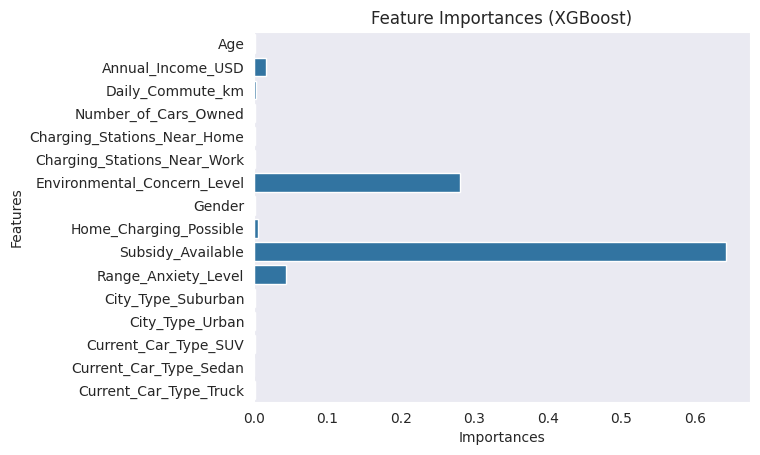

In [36]:
importances = best_xgbc_model.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;"><code>Subsidy_Available</code> (64.3%) and <code>Environmental_Concern_Level</code> (28.0%) together account for ~92% of the tuned XGBoost model's feature importance &mdash; every other feature is nearly negligible by comparison.</li><li style="margin-bottom:4px;">This concentration explains why later tuning, feature engineering and ensembling all produced only marginal gains: most models were already extracting nearly all the signal these two dominant features carry.</li>
</ul>
</div>

<div id="sec4-6" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.6&nbsp;&nbsp;XGBoost (Early Stopping &amp; Seed Ensembling)</h2>
</div>

In [37]:
xgb_es = XGBClassifier(
    **{k: v for k, v in tuned_xgbc_model.best_params_.items() if k != "n_estimators"},
    n_estimators=5000, early_stopping_rounds=100,
    eval_metric="auc", random_state=42, n_jobs=-1
)
xgb_es.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("XGBoost early-stopped AUC:", roc_auc_score(y_val, xgb_es.predict_proba(X_val)[:,1]),
      " best_iteration:", xgb_es.best_iteration)

XGBoost early-stopped AUC: 0.9417995272777171  best_iteration: 774


In [38]:
from sklearn.base import clone

seeds = [42, 7, 123, 2024, 99]
xgb_seed_preds = np.zeros(len(X_val))

for s in seeds:
    m = clone(best_xgbc_model)
    m.set_params(random_state=s)
    m.fit(X_train, y_train)
    xgb_seed_preds += m.predict_proba(X_val)[:, 1] / len(seeds)

print("XGBoost 5-seed average AUC:", roc_auc_score(y_val, xgb_seed_preds))

XGBoost 5-seed average AUC: 0.9417757160564819


<div id="sec4-7" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.7&nbsp;&nbsp;LightGBM (Base)</h2>
</div>

In [39]:
!pip install lightgbm

In [40]:
from lightgbm import LGBMClassifier

lgm = LGBMClassifier(n_jobs=-1, random_state=42)

base_lgm_model = lgm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 622
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061


In [41]:
y_base_lgm_pred = base_lgm_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, base_lgm_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_base_lgm_pred))
print("Classification Report : ")
print(classification_report(y_val, y_base_lgm_pred))

ROC Curve Score:  0.9411234081850752
F1 Score :  0.6965693349616965
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110377
           1       0.72      0.67      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



<div id="sec4-8" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.8&nbsp;&nbsp;LightGBM (Tuned)</h2>
</div>

In [42]:
#  lgbm = LGBMClassifier(
#     objective="binary",
#     random_state=42,
#     n_jobs=1,
#     device_type="gpu",
#     verbosity=-1
# )


# param_dist_lgbm = {
#     "n_estimators": [101, 201, 301, 501],
#     "learning_rate": [0.08, 0.1, 0.2],
#     "num_leaves": [50, 70, 100, 150],
#     "max_depth": [7, 10, 15],
#     "min_child_samples": [30, 50, 100],
#     "subsample": [0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],  
#     "reg_alpha": [0.1, 0.5, 1],
#     "reg_lambda": [0.1, 1, 5, 10],
#     "min_split_gain": [0, 0.1, 0.5]
# }

# lgbm_tuned_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist_lgbm,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=1
# )

# tuned_lgbm_model = lgbm_tuned_search.fit(X_train, y_train)

> Best (from completed fits):  {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 501, 'min_split_gain': 0.1, 'min_child_samples': 50, 'max_depth': 7, 'learning_rate': 0.08, 'colsample_bytree': 0.7}

In [43]:
tuned_lgbm_model = LGBMClassifier(
    subsample= 1.0, reg_lambda=10, reg_alpha=0.1,
    num_leaves=50, n_estimators= 501, min_split_gain= 0.1,
    min_child_samples= 50, max_depth= 7, learning_rate= 0.08,
    colsample_bytree= 0.7, objective="binary", random_state=42,
    n_jobs=1, device_type="gpu", verbosity=-1
)

best_tuned_lgbm_model = tuned_lgbm_model.fit(X_train, y_train)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [44]:
y_best_lgbm_model_pred = best_tuned_lgbm_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, best_tuned_lgbm_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_best_lgbm_model_pred))
print("Classification Report : ")
print(classification_report(y_val, y_best_lgbm_model_pred))

ROC Curve Score:  0.9416771677910446
F1 Score :  0.6979664014146773
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    110377
           1       0.72      0.68      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



<div id="sec4-9" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.9&nbsp;&nbsp;CatBoost (Tuned)</h2>
</div>

In [45]:
# !pip install catboost

# 

# catboost_model = CatBoostClassifier(
#     loss_function="Logloss",
#     eval_metric="Logloss",       # AUC isn't implemented for GPU training; Logloss is — doesn't change your search's scoring
#     task_type="GPU",
#     random_state=42,
#     logging_level="Silent"       # more thorough than verbose=0 — suppresses this class of setup messages to
# )

# param_dist_cat = {
#     "iterations": [300, 500, 800, 1000],
#     "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
#     "depth": [4, 6, 8, 10],
#     "l2_leaf_reg": [1, 3, 5, 7, 10],
#     "border_count": [32, 64, 128],
#     "bagging_temperature": [0, 0.5, 1, 2],
#     "random_strength": [0.5, 1, 2, 5]
# }

# catboost_search = RandomizedSearchCV(
#     estimator=catboost_model,
#     param_distributions=param_dist_cat,
#     n_iter=30,
#     scoring="roc_auc",
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=1
# )

# tuned_catboost_model = catboost_search.fit(X_train, y_train)

In [46]:
from catboost import CatBoostClassifier

# {'random_strength': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 800, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0.5}
tuned_model = CatBoostClassifier(
    random_strength= 2, learning_rate= 0.03, l2_leaf_reg= 7,
    iterations= 800, depth= 6, border_count= 128, bagging_temperature= 0.5, logging_level="Silent", loss_function="Logloss",
    eval_metric="Logloss", task_type="GPU", random_state=42,
)

best_catboost_model = tuned_model.fit(X_train, y_train)

In [47]:
y_tuned_cat_pred = best_catboost_model.predict(X_val)

print("ROC Curve Score: ", roc_auc_score(y_val, best_catboost_model.predict_proba(X_val)[:,1]))  # X_val, not X_val_scaled
print("F1 Score : ", f1_score(y_val, y_tuned_cat_pred))
print("Classification Report : ")
print(classification_report(y_val, y_tuned_cat_pred))

ROC Curve Score:  0.9408705223055586
F1 Score :  0.6926019552135299
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110377
           1       0.73      0.66      0.69     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.80      0.82    133733
weighted avg       0.89      0.90      0.90    133733



<div id="sec4-10" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.10&nbsp;&nbsp;Ensembling: Voting, Blending &amp; Stacking</h2>
</div>

In [48]:
from sklearn.ensemble import VotingClassifier

xgb_model = best_xgbc_model
lgbm_model = best_tuned_lgbm_model
catboost_model = best_catboost_model

voting_classifier = VotingClassifier(
    estimators = [
        ('xgb', xgb_model),
        ('catboost', best_catboost_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft'
)
voting_model = voting_classifier.fit(X_train, y_train)

In [49]:
y_voting_model_pred = voting_model.predict(X_val)

print("ROC Score : ", roc_auc_score(y_val, voting_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_voting_model_pred))
print("Classification Report : ")
print(classification_report(y_val, y_voting_model_pred))

ROC Score :  0.9417521466926607
F1 Score :  0.6976238063513214
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110377
           1       0.72      0.67      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



In [50]:
voting_classifier = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model), ('catboost', catboost_model)],
    voting='soft',
    weights=[0.5403, 0.4597, 0.0]
)

voting_model = voting_classifier.fit(X_train, y_train)

In [51]:
y_voting_model_pred = voting_model.predict(X_val)

print("ROC Score : ", roc_auc_score(y_val, voting_model.predict_proba(X_val)[:,1]))
print("F1 Score : ", f1_score(y_val, y_voting_model_pred))
print("Classification Report : ")
print(classification_report(y_val, y_voting_model_pred))

ROC Score :  0.9419080739325352
F1 Score :  0.6986905368577316
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110377
           1       0.72      0.68      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



In [52]:
from scipy.stats import ks_2samp

val_preds = {
    "xgb": best_xgbc_model.predict_proba(X_val)[:, 1],
    "lgbm": best_tuned_lgbm_model.predict_proba(X_val)[:, 1],
    "cat": best_catboost_model.predict_proba(X_val)[:, 1],
}

corr_matrix = pd.DataFrame(val_preds).corr()
print("Validation-set prediction correlation:\n", corr_matrix)

names = list(val_preds.keys())
print("\nKS-statistics between model pairs:")
for i in range(len(names)):
    for j in range(i+1, len(names)):
        stat, _ = ks_2samp(val_preds[names[i]], val_preds[names[j]])
        print(f"{names[i]} vs {names[j]}: KS = {stat:.4f}")

Validation-set prediction correlation:
            xgb      lgbm       cat
xgb   1.000000  0.996697  0.996964
lgbm  0.996697  1.000000  0.994226
cat   0.996964  0.994226  1.000000

KS-statistics between model pairs:
xgb vs lgbm: KS = 0.0143
xgb vs cat: KS = 0.0475
lgbm vs cat: KS = 0.0562


In [53]:
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score

val_preds = {
    "xgb": best_xgbc_model.predict_proba(X_val)[:, 1],
    "lgbm": best_tuned_lgbm_model.predict_proba(X_val)[:, 1],
    "cat": best_catboost_model.predict_proba(X_val)[:, 1],
}

def neg_auc(w):
    w = np.clip(w, 0, None)
    if w.sum() == 0: return 0
    w = w / w.sum()
    blend = sum(w[i] * val_preds[n] for i, n in enumerate(val_preds))
    return -roc_auc_score(y_val, blend)

result = minimize(neg_auc, x0=[1/3, 1/3, 1/3], method="Nelder-Mead")
weights = dict(zip(val_preds.keys(), np.clip(result.x, 0, None) / np.clip(result.x, 0, None).sum()))
print("Optimized weights:", weights)
print("Blended AUC:", -result.fun)

Optimized weights: {'xgb': np.float64(0.5403095085879303), 'lgbm': np.float64(0.4596904914120698), 'cat': np.float64(0.0)}
Blended AUC: 0.9419080781994664


In [54]:
from sklearn.linear_model import LogisticRegression

stack_X_val = np.column_stack([val_preds["xgb"], val_preds["lgbm"], val_preds["cat"]])
stacker = LogisticRegression()
stacker.fit(stack_X_val, y_val)
stack_pred = stacker.predict_proba(stack_X_val)[:, 1]
print("Stacked AUC (in-sample, just a quick check):", roc_auc_score(y_val, stack_pred))

Stacked AUC (in-sample, just a quick check): 0.9417575160436262


<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">XGBoost, LightGBM and CatBoost predictions correlate at 0.994&ndash;0.997 on the validation set &mdash; the three models are extracting almost the same signal, which is why voting, blending and stacking all landed within ~0.0002 of the best single model (0.9417&ndash;0.9419).</li><li style="margin-bottom:4px;">KS-statistics show CatBoost differs most from the other two (0.048&ndash;0.056 vs. 0.014 for XGBoost/LightGBM), but the optimizer still assigned it <b>zero weight</b> in the best blend &mdash; being different isn't the same as being useful; CatBoost was consistently the weakest individual model.</li><li style="margin-bottom:4px;">Conclusion: this feature set has a practical ceiling around AUC&nbsp;0.9417&ndash;0.9419 for tree/linear models trained on it as-is &mdash; closing the gap further required new information, not more tuning or combining.</li>
</ul>
</div>

<div id="sec4-11" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.11&nbsp;&nbsp;Final Model: Long-Trained LightGBM + Binned Target Encoding</h2>
</div>

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Approach</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">Two changes broke past the ~0.9419 ceiling: (1) a much longer, slower-learning LightGBM (<code>n_estimators=15000, learning_rate=0.02</code> with early stopping) instead of the short, fast-tuned runs used earlier, and (2) fold-safe target encoding of <b>binned</b> continuous features (<code>Annual_Income_USD</code> and <code>Daily_Commute_km</code> floored to coarser buckets) using <code>sklearn.preprocessing.TargetEncoder</code>, which exposes threshold-like effects that raw numeric splits were missing.</li>
</ul>
</div>

In [55]:
import lightgbm as lgb
from lightgbm import LGBMClassifier


from sklearn.preprocessing import TargetEncoder

# Bin continuous features into pseudo-categorical strings
X_binned = X.copy()
X_binned["Income_floor_100"] = (X["Annual_Income_USD"] // 100).astype(str)
X_binned["Income_floor_1000"] = (X["Annual_Income_USD"] // 1000).astype(str)
X_binned["Commute_floor"] = X["Daily_Commute_km"].astype(int).astype(str)

te = TargetEncoder(cv=5, smooth="auto", random_state=42)
te_cols = ["Income_floor_100", "Income_floor_1000", "Commute_floor"]
X_binned[[f"{c}_TE" for c in te_cols]] = te.fit_transform(X_binned[te_cols], y)
X_binned = X_binned.drop(columns=te_cols)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X_binned, y, test_size=0.2, random_state=42, stratify=y)

lgbm_long = LGBMClassifier(
    n_estimators=15000, learning_rate=0.02, max_depth=5, num_leaves=32,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.3,
    reg_alpha=0.071, reg_lambda=2.0, random_state=42, n_jobs=-1, verbosity=-1
)
lgbm_long.fit(X_train_b, y_train_b, eval_set=[(X_val_b, y_val_b)],
              callbacks=[lgb.early_stopping(400, verbose=False)])
print("AUC:", roc_auc_score(y_val_b, lgbm_long.predict_proba(X_val_b)[:,1]))

AUC: 0.9441410674086319


In [56]:
# Fresh binned frame — raw bin columns still present, not yet target-encoded
from sklearn.model_selection import StratifiedKFold

X_binned_raw = X.copy()
X_binned_raw["Income_floor_100"] = (X["Annual_Income_USD"] // 100).astype(str)
X_binned_raw["Income_floor_1000"] = (X["Annual_Income_USD"] // 1000).astype(str)
X_binned_raw["Commute_floor"] = X["Daily_Commute_km"].astype(int).astype(str)

te_cols = ["Income_floor_100", "Income_floor_1000", "Commute_floor"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X_binned_raw))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_binned_raw, y), 1):
    X_tr, y_tr = X_binned_raw.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X_binned_raw.iloc[va_idx], y.iloc[va_idx]

    te_fold = TargetEncoder(cv=5, smooth="auto", random_state=42)
    X_tr_enc = X_tr.copy(); X_va_enc = X_va.copy()
    X_tr_enc[[f"{c}_TE" for c in te_cols]] = te_fold.fit_transform(X_tr[te_cols], y_tr)
    X_va_enc[[f"{c}_TE" for c in te_cols]] = te_fold.transform(X_va[te_cols])
    X_tr_enc = X_tr_enc.drop(columns=te_cols); X_va_enc = X_va_enc.drop(columns=te_cols)

    m = clone(lgbm_long)
    m.fit(X_tr_enc, y_tr, eval_set=[(X_va_enc, y_va)], callbacks=[lgb.early_stopping(400, verbose=False)])
    oof[va_idx] = m.predict_proba(X_va_enc)[:,1]
    print(f"Fold {fold} AUC:", roc_auc_score(y_va, oof[va_idx]))

print("Overall OOF AUC:", roc_auc_score(y, oof))

Fold 1 AUC: 0.9433293095202453
Fold 2 AUC: 0.9441830621568528
Fold 3 AUC: 0.9452055619903378
Fold 4 AUC: 0.9447595202847913
Fold 5 AUC: 0.9444299615320022
Overall OOF AUC: 0.9443748839567857


<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">5-fold out-of-fold AUC: <b>0.9444</b> (range 0.9433&ndash;0.9452 across folds), up from the ~0.9419 ceiling reached by every other model and ensembling technique tried in Section 4.10.</li><li style="margin-bottom:4px;">This is the model used for the final submission in Section 6.</li>
</ul>
</div>

<div id="sec5" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">5.&nbsp;&nbsp;Summary &amp; Conclusion</h1>
</div>

<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Model Comparison</h3>

| Model | ROC-AUC |
|---|---|
| Logistic Regression (balanced) | 0.9380 |
| Logistic Regression (L2, balanced) | 0.9380 |
| Random Forest | 0.9333 |
| XGBoost (base) | 0.9411 |
| XGBoost (tuned) | 0.9417 |
| XGBoost (early-stopped) | 0.9418 |
| XGBoost (5-seed average) | 0.9418 |
| LightGBM (base) | 0.9411 |
| LightGBM (tuned) | 0.9417 |
| CatBoost (tuned) | 0.9409 |
| Voting Classifier (soft, equal weight) | 0.9418 |
| Weighted blend (optimized) | 0.9419 |
| Stacked (Logistic Regression meta-model) | 0.9418 |
| **LightGBM + Binned Target Encoding (5-fold OOF)** | **0.9444** |

<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Winner: LightGBM with Binned Target Encoding</h3>

**Best model:** Long-trained LightGBM (`n_estimators=15000`, `learning_rate=0.02`, early stopping) on features augmented with fold-safe target-encoded income/commute bins
**Out-of-fold ROC-AUC:** 0.9444

**Why it won:**
- Every model trained directly on the original feature set &mdash; regardless of family (linear, bagged trees, three different boosting libraries) or how much it was tuned &mdash; converged to the same narrow band of 0.9333&ndash;0.9419. That convergence across fundamentally different algorithms was a strong signal the *feature set*, not the *model*, was the limiting factor.
- Binning `Annual_Income_USD` and `Daily_Commute_km` into coarser buckets and target-encoding those buckets exposed threshold-like structure that raw numeric splits in tree models weren't capturing on their own.
- Training much longer at a much lower learning rate (`15000` estimators at `lr=0.02` vs. the `~500` estimators typically found by hyperparameter search) gave the model room to use that new information fully, with early stopping preventing overfitting.

<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Key Findings</h3>
- A column-reordering bug (`df.columns = [...]` instead of `df = df[cols]`) silently corrupted the training target for an entire round of early experiments &mdash; caught by manually verifying row values against the raw CSV, not by any error or warning.
- `Subsidy_Available` and `Environmental_Concern_Level` dominate feature importance (~92% combined) across every tree-based model tried.
- XGBoost, LightGBM and CatBoost predictions correlate at 0.994&ndash;0.997 on this feature set, explaining why ensembling techniques (voting, weighted blending, stacking) only ever produced marginal gains over the single best model.
- The real gain came from **new information** (finer-grained binned target encoding) and **more training capacity** (longer, slower LightGBM), not from further tuning or combining models that were already extracting nearly the same signal.


<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Limitations &amp; Potential Improvements</h3>
- The 5-fold OOF estimate (0.9444) is the most reliable local number, but the actual leaderboard score may differ slightly, since local CV and the public/private leaderboard splits aren't identical.
- Applying the same binned target encoding + long-training approach to XGBoost and CatBoost, then re-blending, was identified as a promising next step but not yet completed.
- A reference "grandmaster ensemble" notebook (LB 0.94656) was reviewed for ideas: its fold-safe target encoding and long-training approach was legitimate and is what this notebook adopted; its final public-leaderboard "calibration" step (hand-tuned rank-shuffling constants with no statistical justification) was identified as leaderboard probing rather than real modeling and was deliberately **not** used here.

<div id="sec6" style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">6.&nbsp;&nbsp;Test Set Inference &amp; Submission</h1>
</div>

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">Rebuilds fresh <code>city_ohe</code>/<code>car_ohe</code> encoders instead of reusing Section 3.1's <code>ohe</code> variable &mdash; that variable was fit twice (once for <code>City_Type</code>, then reassigned when fit again for <code>Current_Car_Type</code>), so it currently only holds the car-type encoder. Refitting fresh encoders on the same raw <code>train.csv</code> reproduces identical categories safely.</li>
</ul>
</div>

In [57]:
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
test_ids = test_df["id"]

raw_train_for_ohe = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")

city_ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
city_ohe.fit(raw_train_for_ohe[["City_Type"]])

car_ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
car_ohe.fit(raw_train_for_ohe[["Current_Car_Type"]])

def preprocess(df_):
    df_ = df_.copy()
    df_["Home_Charging_Possible"] = charging_le.transform(df_["Home_Charging_Possible"])
    df_["Subsidy_Available"]      = subsidy_le.transform(df_["Subsidy_Available"])
    df_["Range_Anxiety_Level"]    = df_["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
    df_["Gender"]                 = df_["Gender"].map({"Male": 0, "Female": 1, "Other": 2})

    city_enc = pd.DataFrame(
        city_ohe.transform(df_[["City_Type"]]),
        columns=city_ohe.get_feature_names_out(["City_Type"]), index=df_.index
    )
    car_enc = pd.DataFrame(
        car_ohe.transform(df_[["Current_Car_Type"]]),
        columns=car_ohe.get_feature_names_out(["Current_Car_Type"]), index=df_.index
    )

    df_ = pd.concat([df_.drop(columns=["City_Type", "Current_Car_Type"]), city_enc, car_enc], axis=1)
    if "id" in df_.columns:
        df_ = df_.drop(columns=["id"])
    return df_

preprocess(test_df)[X.columns].head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck
0,61,67725.0,16.9,2,7,4,4.0,0,1,0,0,1.0,0.0,0.0,1.0,0.0
1,42,152835.0,41.9,2,9,9,4.0,0,0,0,0,0.0,1.0,1.0,0.0,0.0
2,68,86877.0,53.3,1,10,11,4.0,1,0,0,0,0.0,1.0,0.0,1.0,0.0
3,39,46794.0,34.1,2,4,8,4.0,1,1,0,0,1.0,0.0,0.0,1.0,0.0
4,55,112172.0,57.2,1,6,4,1.0,1,1,1,0,1.0,0.0,0.0,1.0,0.0


<div id="sec6-2" style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">6.2&nbsp;&nbsp;Generating Final Predictions</h2>
</div>

In [58]:
test_processed_binned = preprocess(test_df)[X.columns]
test_processed_binned["Income_floor_100"] = (test_processed_binned["Annual_Income_USD"] // 100).astype(str)
test_processed_binned["Income_floor_1000"] = (test_processed_binned["Annual_Income_USD"] // 1000).astype(str)
test_processed_binned["Commute_floor"] = test_processed_binned["Daily_Commute_km"].astype(int).astype(str)

test_preds = np.zeros(len(test_processed_binned))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_binned_raw, y), 1):
    X_tr, y_tr = X_binned_raw.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X_binned_raw.iloc[va_idx], y.iloc[va_idx]

    te_fold = TargetEncoder(cv=5, smooth="auto", random_state=42)
    X_tr_enc = X_tr.copy(); X_va_enc = X_va.copy()
    X_tr_enc[[f"{c}_TE" for c in te_cols]] = te_fold.fit_transform(X_tr[te_cols], y_tr)
    X_va_enc[[f"{c}_TE" for c in te_cols]] = te_fold.transform(X_va[te_cols])
    X_tr_enc = X_tr_enc.drop(columns=te_cols); X_va_enc = X_va_enc.drop(columns=te_cols)

    test_enc = test_processed_binned.copy()
    test_enc[[f"{c}_TE" for c in te_cols]] = te_fold.transform(test_processed_binned[te_cols])
    test_enc = test_enc.drop(columns=te_cols)

    m = clone(lgbm_long)
    m.fit(X_tr_enc, y_tr, eval_set=[(X_va_enc, y_va)], callbacks=[lgb.early_stopping(400, verbose=False)])
    test_preds += m.predict_proba(test_enc)[:, 1] / skf.n_splits
    print(f"Fold {fold} done — best_iteration: {m.best_iteration_}")

submission = pd.DataFrame({"id": test_ids, "Will_Buy_EV": test_preds})
submission.to_csv("submission.csv", index=False)

Fold 1 done — best_iteration: 2017
Fold 2 done — best_iteration: 1944
Fold 3 done — best_iteration: 2034
Fold 4 done — best_iteration: 1930
Fold 5 done — best_iteration: 2289


In [59]:
print("Submission shape:", submission.shape)
submission.head()

Submission shape: (286571, 2)


,id,Will_Buy_EV
0,668665,0.012831
1,668666,0.014424
2,668667,0.004671
3,668668,0.001837
4,668669,0.021975
